# 2. Обучение модели Schema Matching

Пайплайн обучения ProjectionHead с Triplet Loss для сопоставления столбцов.

Процесс:
1. Загрузка конфига и датасета из Pipeline 1
2. Обучение модели (Triplet Loss + mining)
3. Визуальный анализ (t-SNE до/после обучения)
4. Статистический анализ (loss curves, separability, test metrics)

## 2.1 Загрузка конфигурации

In [1]:
import json
import os
import logging

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
logger = logging.getLogger(__name__)

CONFIG_PATH = 'config.json'

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    full_config = json.load(f)

data_gen_params = full_config['data_generation']
sm_params = full_config['schema_matching']

# Пути к данным из Pipeline 1
SM_DATASET_PATH = os.path.join(data_gen_params['output_dir'], data_gen_params['sm_dataset_file'])
SM_MODEL_DIR = sm_params['model_dir']

print(f"Датасет: {SM_DATASET_PATH}")
print(f"Модели: {SM_MODEL_DIR}")
print(f"Архитектура: projection_dims={sm_params['projection_dims']}, output_dim={sm_params['output_dim']}")
print(f"Обучение: epochs={sm_params['num_epochs']}, lr={sm_params['learning_rate']}, "
      f"margin={sm_params['margin']}, mining={sm_params['mining_strategy']}")

Датасет: unified_dataset\sm_dataset.json
Модели: sm_models
Архитектура: projection_dims=[2048, 1024, 512], output_dim=256
Обучение: epochs=30, lr=0.001, margin=0.2, mining=semihard


## 2.2 Анализ датасета перед обучением

2026-03-06 09:19:52,741 [INFO] Загрузка датасета: unified_dataset\sm_dataset.json
2026-03-06 09:20:00,674 [INFO] Всего записей: 12288
2026-03-06 09:20:01,818 [INFO] SMDataset: 8596 samples, 19 classes, embed_dim=4096
2026-03-06 09:20:02,060 [INFO] SMDataset: 1839 samples, 19 classes, embed_dim=4096
2026-03-06 09:20:02,305 [INFO] SMDataset: 1853 samples, 19 classes, embed_dim=4096
2026-03-06 09:20:02,305 [INFO] Train: 8596, Val: 1839, Test: 1853
2026-03-06 09:20:02,305 [INFO] Classes: 19, Embed dim: 4096


Train: 8596 samples, Val: 1839, Test: 1853
Классов: 19
Размерность эмбеддинга: 4096


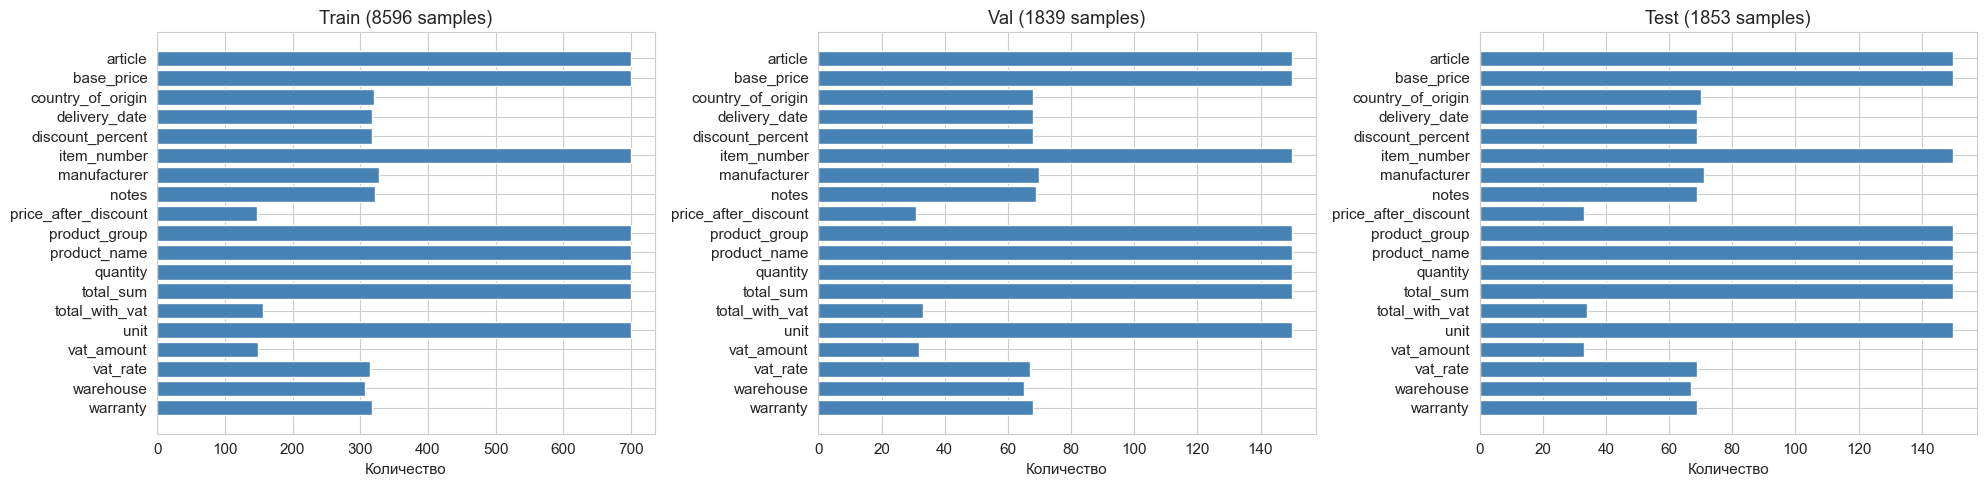

In [2]:
from table_unifier.schema_matching.dataset import load_and_split_dataset

train_ds, val_ds, test_ds = load_and_split_dataset(
    SM_DATASET_PATH,
    train_ratio=sm_params['train_ratio'],
    val_ratio=sm_params['val_ratio'],
    test_ratio=sm_params['test_ratio'],
)

print(f"Train: {len(train_ds)} samples, Val: {len(val_ds)}, Test: {len(test_ds)}")
print(f"Классов: {train_ds.num_classes}")
print(f"Размерность эмбеддинга: {train_ds.embed_dim}")

# Распределение по классам в каждом сплите
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (ds, name) in zip(axes, [(train_ds, 'Train'), (val_ds, 'Val'), (test_ds, 'Test')]):
    dist = ds.get_class_distribution()
    names = sorted(dist.keys())
    counts = [dist[n] for n in names]
    ax.barh(names, counts, color='steelblue')
    ax.set_title(f'{name} ({len(ds)} samples)')
    ax.set_xlabel('Количество')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

C:\Users\olegk\AppData\Local\Temp\ipykernel_3480\1912755.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_labels))


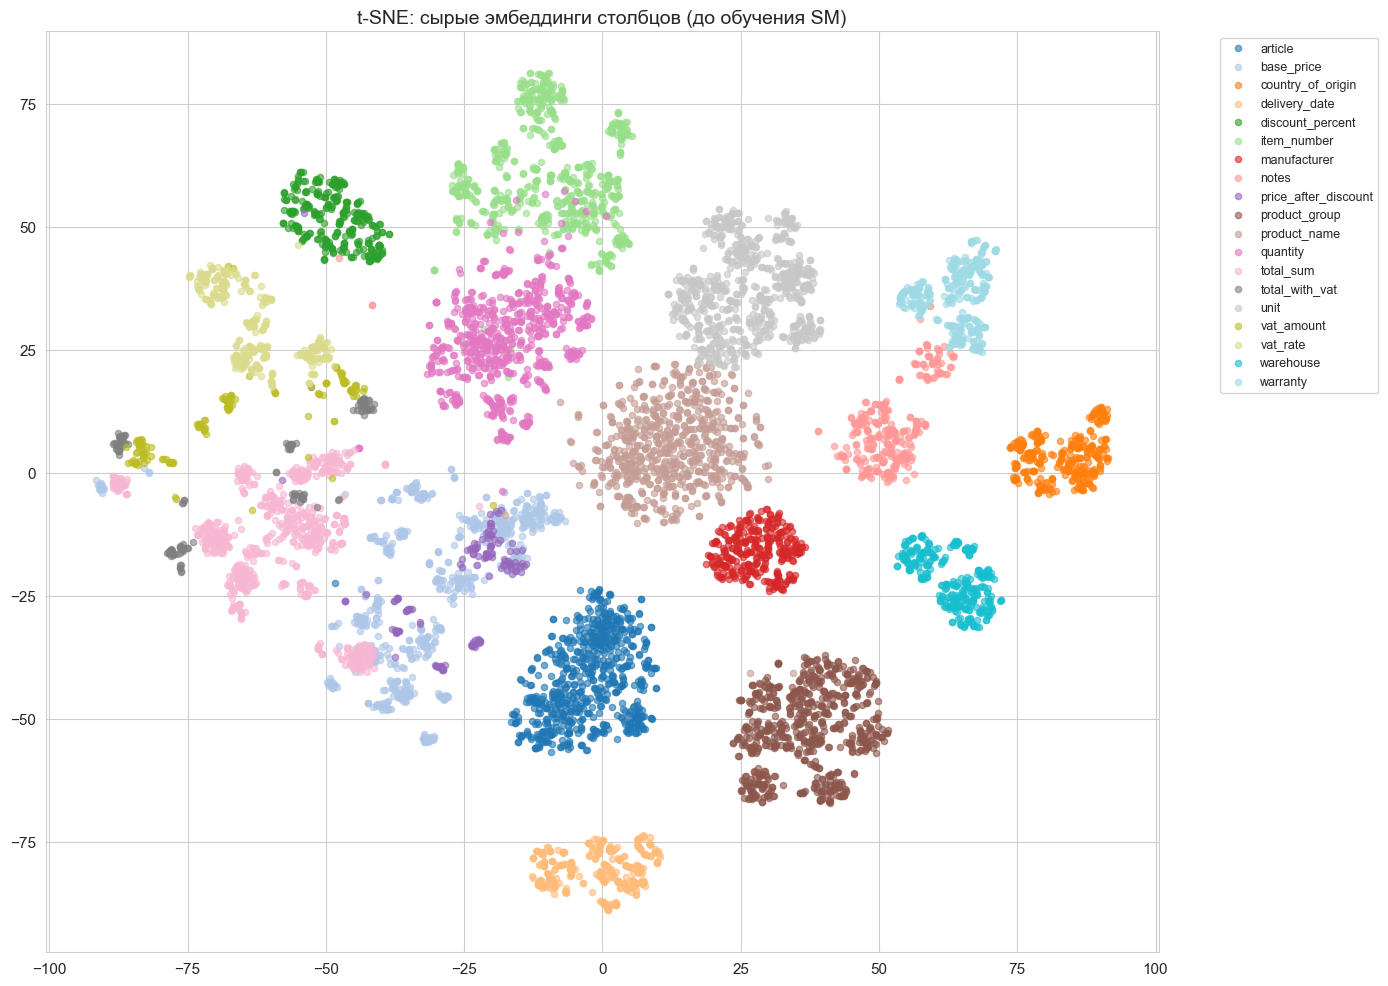

In [11]:
# t-SNE сырых эмбеддингов (до обучения)
raw_embeddings = train_ds.embeddings.numpy()
raw_labels = [train_ds.idx2label[l.item()] for l in train_ds.labels]

tsne_raw = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_raw_result = tsne_raw.fit_transform(raw_embeddings)

unique_labels = sorted(set(raw_labels))
cmap = plt.cm.get_cmap('tab20', len(unique_labels))

fig, ax = plt.subplots(figsize=(14, 10))
for i, label in enumerate(unique_labels):
    mask = np.array(raw_labels) == label
    ax.scatter(tsne_raw_result[mask, 0], tsne_raw_result[mask, 1],
               c=[cmap(i)], label=label, alpha=0.6, s=20)

ax.set_title('t-SNE: сырые эмбеддинги столбцов (до обучения SM)', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 2.3 Обучение модели

In [3]:
from table_unifier.schema_matching import SMConfig, SMTrainer

# Строим SMConfig: параметры Ollama из data_gen + SM-специфичные
sm_config = SMConfig(
    ollama_host=data_gen_params['ollama_host'],
    llm_model=data_gen_params['llm_model'],
    embedding_model=data_gen_params['embedding_model'],
    # Архитектура
    projection_dims=sm_params['projection_dims'],
    output_dim=sm_params['output_dim'],
    dropout=sm_params['dropout'],
    use_batch_norm=sm_params['use_batch_norm'],
    # Обучение
    batch_size=sm_params['batch_size'],
    learning_rate=sm_params['learning_rate'],
    weight_decay=sm_params['weight_decay'],
    num_epochs=sm_params['num_epochs'],
    margin=sm_params['margin'],
    mining_strategy=sm_params['mining_strategy'],
    scheduler_patience=sm_params['scheduler_patience'],
    early_stopping_patience=sm_params['early_stopping_patience'],
    train_ratio=sm_params['train_ratio'],
    val_ratio=sm_params['val_ratio'],
    test_ratio=sm_params['test_ratio'],
    # Порог
    similarity_threshold=sm_params['similarity_threshold'],
    model_dir=sm_params['model_dir'],
)

trainer = SMTrainer(sm_config)
print(f"Device: {trainer.device}")

2026-03-06 09:20:10,636 [INFO] input_dim автоматически определён из 'qwen3-embedding:8b': 4096
2026-03-06 09:20:10,647 [INFO] SMTrainer: device=cuda


Device: cuda


In [4]:
history = trainer.train(
    dataset_path=SM_DATASET_PATH,
    save_dir=SM_MODEL_DIR,
)

print(f"\nОбучение завершено. Модель сохранена в {SM_MODEL_DIR}/")

2026-03-06 09:20:16,835 [INFO] Загрузка датасета: unified_dataset\sm_dataset.json
2026-03-06 09:20:24,853 [INFO] Всего записей: 12288
2026-03-06 09:20:26,003 [INFO] SMDataset: 8596 samples, 19 classes, embed_dim=4096
2026-03-06 09:20:26,247 [INFO] SMDataset: 1839 samples, 19 classes, embed_dim=4096
2026-03-06 09:20:26,492 [INFO] SMDataset: 1853 samples, 19 classes, embed_dim=4096
2026-03-06 09:20:26,493 [INFO] Train: 8596, Val: 1839, Test: 1853
2026-03-06 09:20:26,493 [INFO] Classes: 19, Embed dim: 4096
2026-03-06 09:20:26,560 [INFO] ProjectionHead: 4096 → [2048, 1024, 512] → 256, 11,152,128 params
2026-03-06 09:20:26,642 [INFO] Модель: 11,152,128 параметров
2026-03-06 09:20:29,944 [INFO] Mining strategy: semihard
2026-03-06 09:20:29,944 [INFO] Margin: 0.2
2026-03-06 09:20:29,945 [INFO] 
Начало обучения: 30 эпох
2026-03-06 09:20:29,945 [INFO] Train: 8596, Val: 1839, Test: 1853
2026-03-06 09:20:29,945 [INFO] Batch size: 64
2026-03-06 09:20:29,945 [INFO] ---------------------------------


Обучение завершено. Модель сохранена в sm_models/


## 2.4 Кривые обучения

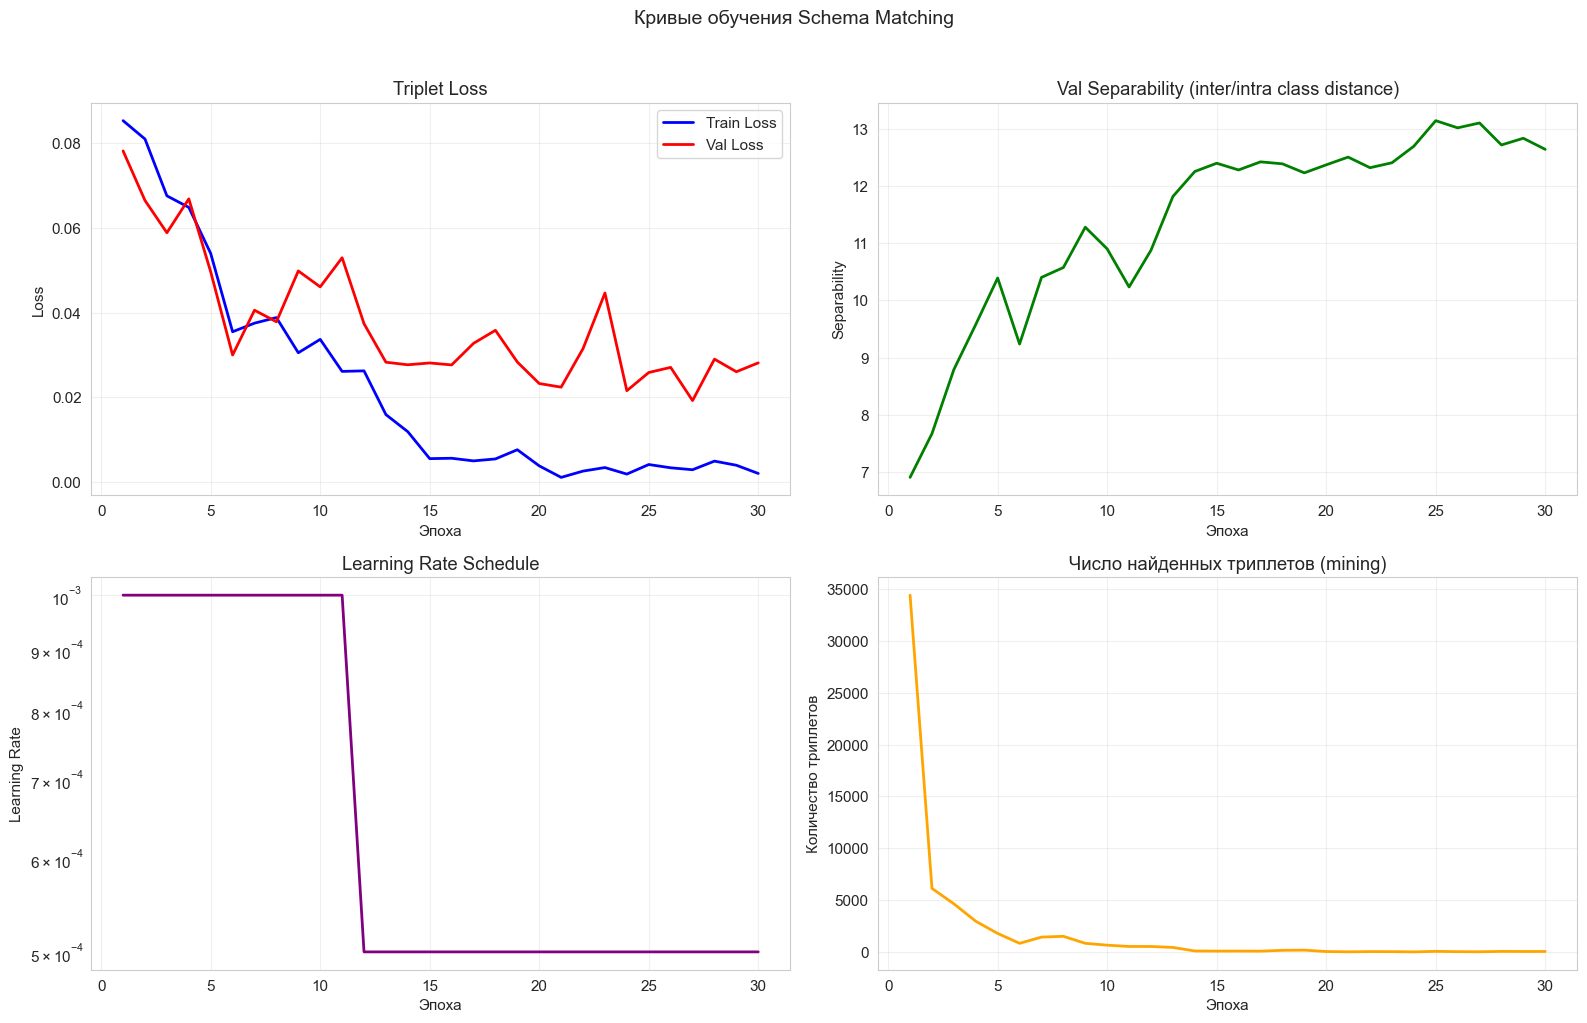

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Triplet Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Separability
axes[0, 1].plot(epochs, history['val_separability'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Separability')
axes[0, 1].set_title('Val Separability (inter/intra class distance)')
axes[0, 1].grid(True, alpha=0.3)

# Learning rate
axes[1, 0].plot(epochs, history['learning_rate'], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3)

# Triplets
axes[1, 1].plot(epochs, history['train_triplets'], 'orange', linewidth=2)
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Количество триплетов')
axes[1, 1].set_title('Число найденных триплетов (mining)')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Кривые обучения Schema Matching', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.5 Визуализация t-SNE (до и после обучения)

In [9]:
from table_unifier.schema_matching.model import SchemaMatchingModel

# Загружаем лучшую модель
best_model = SchemaMatchingModel.load(
    os.path.join(SM_MODEL_DIR, 'best_model.pt'),
    device='cpu'
)
best_model.eval()

# Проецируем эмбеддинги через обученную модель
with torch.no_grad():
    projected = best_model(train_ds.embeddings).numpy()

# t-SNE на проецированных эмбеддингах
tsne_proj = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_proj_result = tsne_proj.fit_transform(projected)

2026-03-06 09:27:58,258 [INFO] ProjectionHead: 4096 → [2048, 1024, 512] → 256, 11,152,128 params
2026-03-06 09:27:58,261 [INFO] Модель загружена: sm_models\best_model.pt


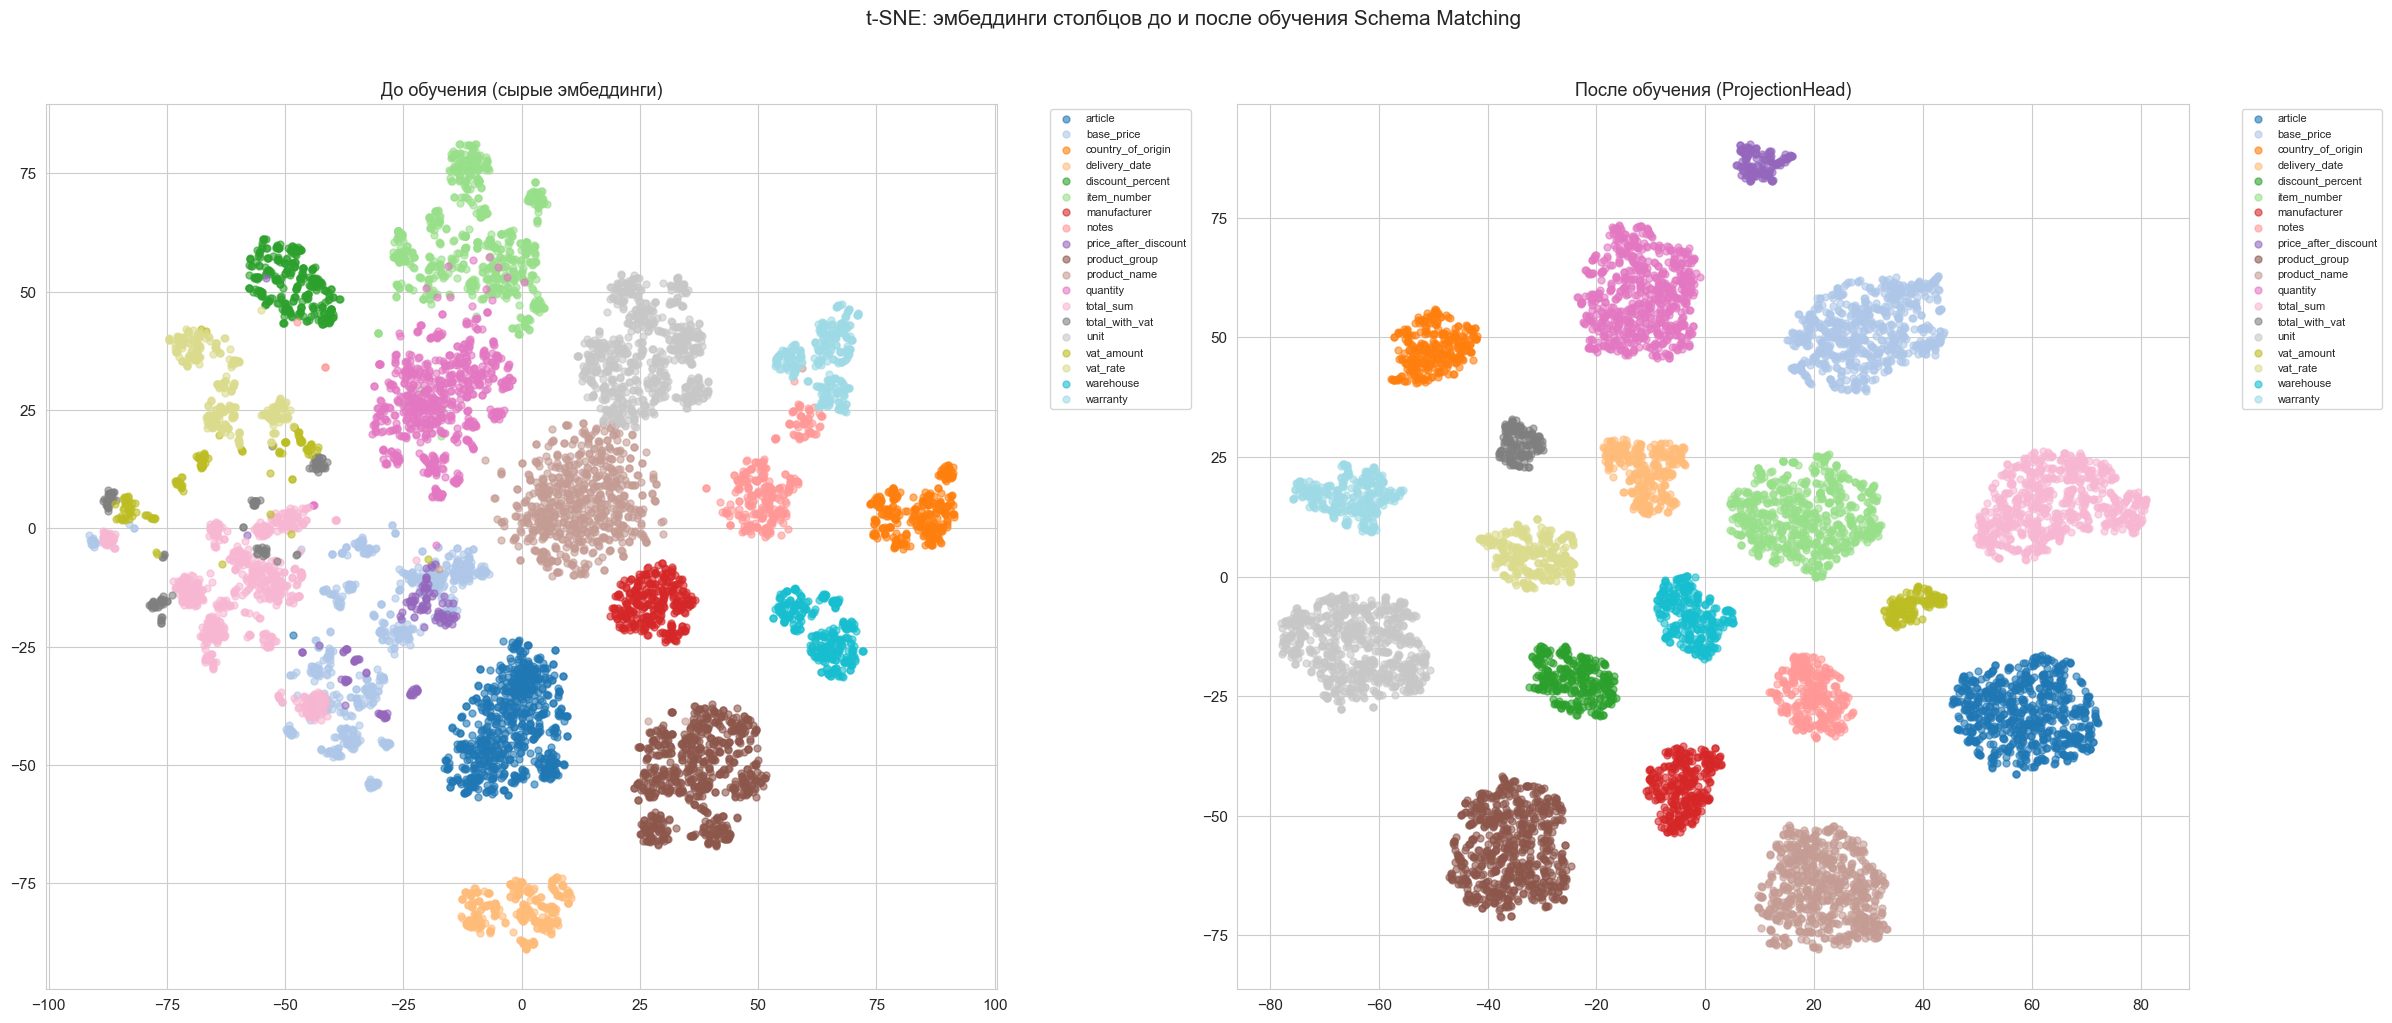

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

for ax, tsne_data, title in [
    (axes[0], tsne_raw_result, 'До обучения (сырые эмбеддинги)'),
    (axes[1], tsne_proj_result, 'После обучения (ProjectionHead)'),
]:
    for i, label in enumerate(unique_labels):
        mask = np.array(raw_labels) == label
        ax.scatter(tsne_data[mask, 0], tsne_data[mask, 1],
                   c=[cmap(i)], label=label, alpha=0.6, s=25)
    ax.set_title(title, fontsize=13)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.suptitle('t-SNE: эмбеддинги столбцов до и после обучения Schema Matching', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 2.6 Матрица сходства (после обучения)

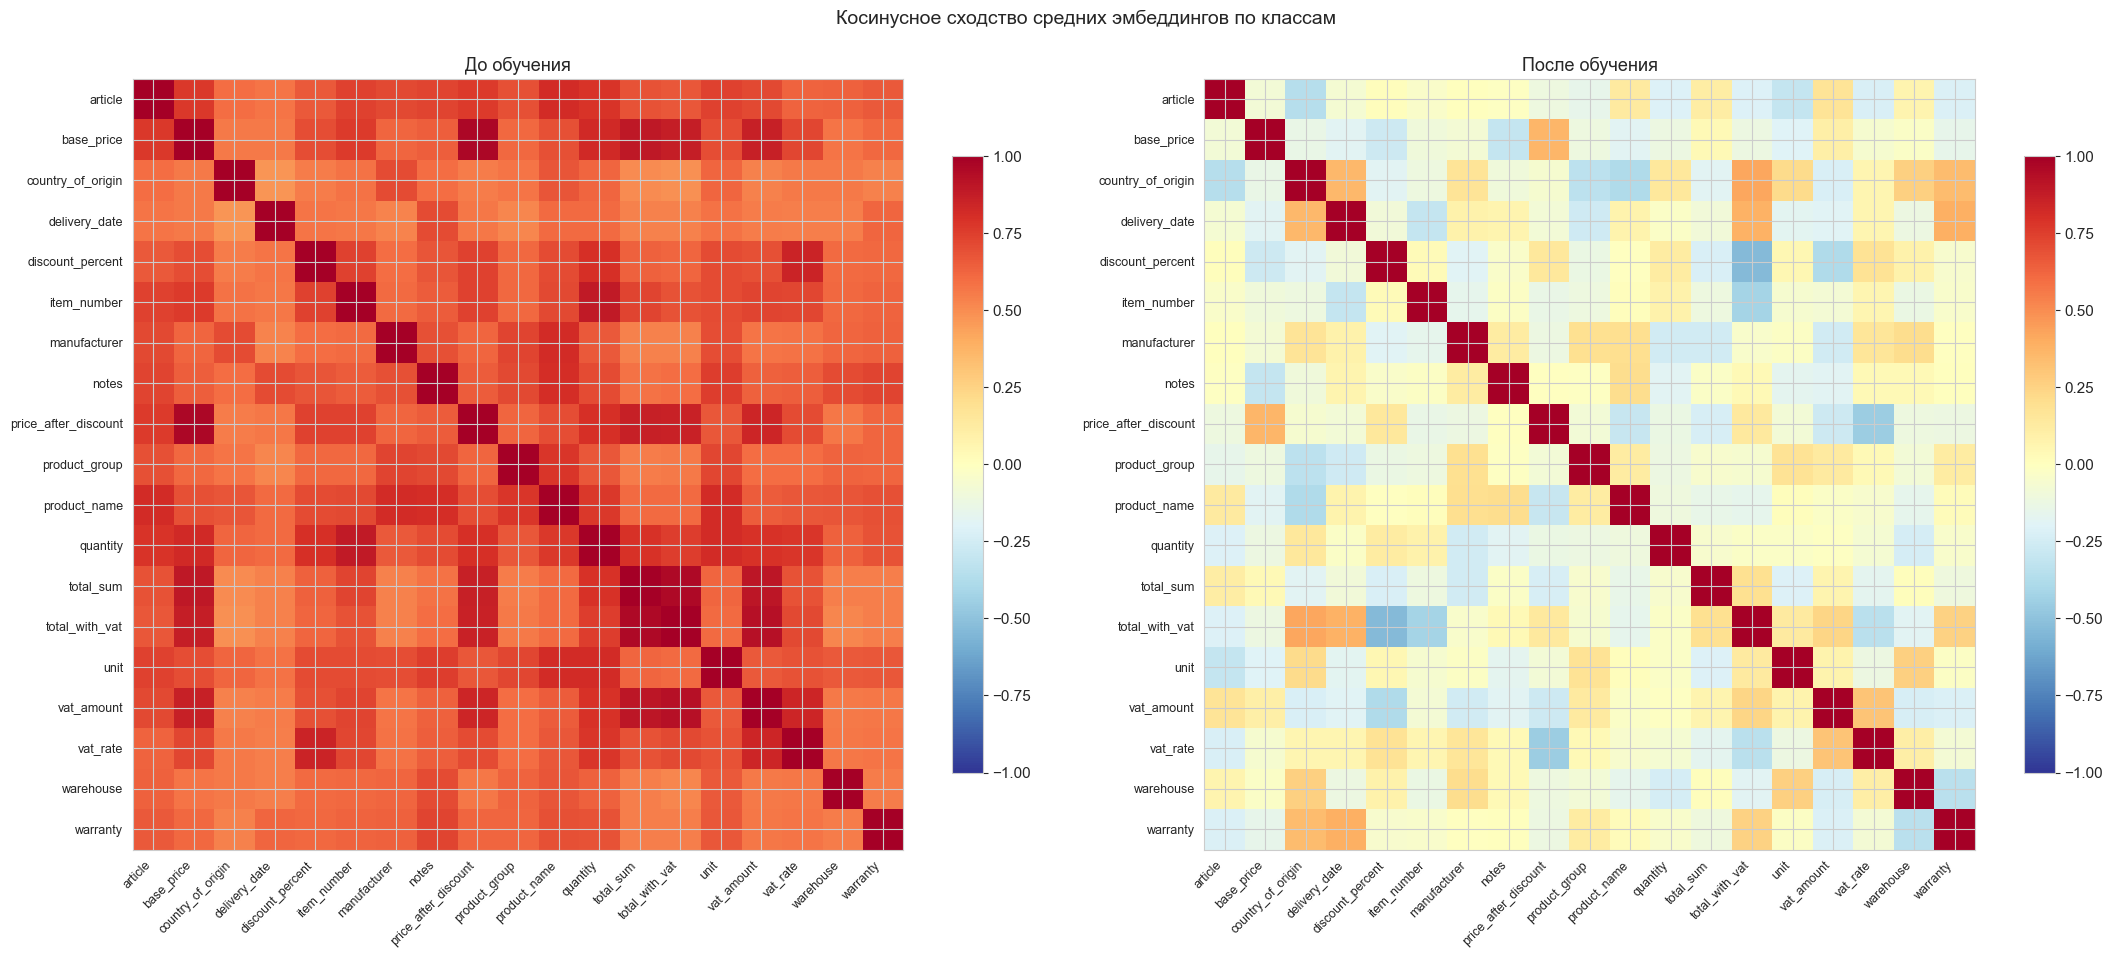

In [13]:
# Матрица косинусных сходств средних проецированных эмбеддингов
class_projected = {}
for emb, label_idx in zip(projected, train_ds.labels.numpy()):
    label = train_ds.idx2label[label_idx]
    class_projected.setdefault(label, []).append(emb)

class_names_sorted = sorted(class_projected.keys())
mean_proj = np.array([np.mean(class_projected[c], axis=0) for c in class_names_sorted])

sim_after = cosine_similarity(mean_proj)

# Также для сравнения — до обучения
class_raw = {}
for emb, label_idx in zip(raw_embeddings, train_ds.labels.numpy()):
    label = train_ds.idx2label[label_idx]
    class_raw.setdefault(label, []).append(emb)

mean_raw = np.array([np.mean(class_raw[c], axis=0) for c in class_names_sorted])
sim_before = cosine_similarity(mean_raw)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, sim, title in [
    (axes[0], sim_before, 'До обучения'),
    (axes[1], sim_after, 'После обучения'),
]:
    im = ax.imshow(sim, cmap='RdYlBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(class_names_sorted)))
    ax.set_yticks(range(len(class_names_sorted)))
    ax.set_xticklabels(class_names_sorted, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names_sorted, fontsize=9)
    ax.set_title(title, fontsize=13)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Косинусное сходство средних эмбеддингов по классам', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.7 Метрики на тестовой выборке

In [14]:
# Загружаем результаты обучения
results_path = os.path.join(SM_MODEL_DIR, 'training_results.json')
with open(results_path, 'r', encoding='utf-8') as f:
    results = json.load(f)

print("=" * 60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 60)
print(f"\nЛучшая эпоха: {results['best_epoch']}")
print(f"Best Val Loss: {results['best_val_loss']:.4f}")
print(f"\nТестовые метрики:")
for k, v in results.get('test_metrics', {}).items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

print(f"\nДатасет:")
for k, v in results.get('dataset', {}).items():
    print(f"  {k}: {v}")

РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ

Лучшая эпоха: 27
Best Val Loss: 0.0193

Тестовые метрики:
  separability: 13.4562
  accuracy_at_1: 0.9951
  mean_intra_dist: 0.1398
  mean_inter_dist: 1.4493
  num_test_samples: 1853
  num_classes: 19

Датасет:
  train_samples: 8596
  val_samples: 1839
  test_samples: 1853
  num_classes: 19
  embed_dim: 4096


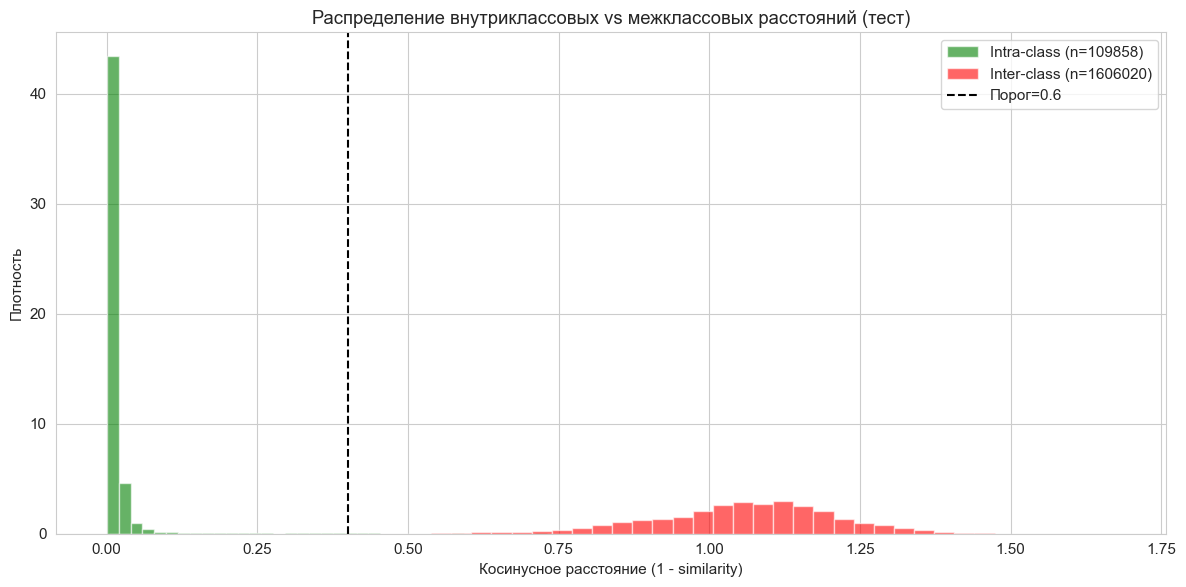

Intra-class расстояния: mean=0.0163, std=0.0486
Inter-class расстояния: mean=1.0562, std=0.1557
Separability ratio: 64.85


In [15]:
# Анализ качества: intra- vs inter-class distances
with torch.no_grad():
    test_projected = best_model(test_ds.embeddings).numpy()

test_labels = [test_ds.idx2label[l.item()] for l in test_ds.labels]

# Внутриклассовые и межклассовые расстояния
intra_dists = []
inter_dists = []

sim_all = cosine_similarity(test_projected)
for i in range(len(test_labels)):
    for j in range(i + 1, len(test_labels)):
        dist = 1 - sim_all[i, j]
        if test_labels[i] == test_labels[j]:
            intra_dists.append(dist)
        else:
            inter_dists.append(dist)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(intra_dists, bins=50, alpha=0.6, label=f'Intra-class (n={len(intra_dists)})', color='green', density=True)
ax.hist(inter_dists, bins=50, alpha=0.6, label=f'Inter-class (n={len(inter_dists)})', color='red', density=True)
ax.set_xlabel('Косинусное расстояние (1 - similarity)')
ax.set_ylabel('Плотность')
ax.set_title('Распределение внутриклассовых vs межклассовых расстояний (тест)')
ax.legend(fontsize=12)
ax.axvline(1 - sm_params['similarity_threshold'], color='black', linestyle='--', 
           label=f'Порог={sm_params["similarity_threshold"]}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Intra-class расстояния: mean={np.mean(intra_dists):.4f}, std={np.std(intra_dists):.4f}")
print(f"Inter-class расстояния: mean={np.mean(inter_dists):.4f}, std={np.std(inter_dists):.4f}")
print(f"Separability ratio: {np.mean(inter_dists) / np.mean(intra_dists):.2f}")

In [16]:
# Accuracy@1 на тесте: для каждого сэмпла ищем ближайшего, проверяем совпадение классов
test_sim = cosine_similarity(test_projected)
np.fill_diagonal(test_sim, -1)  # исключаем самого себя

correct = 0
total = len(test_labels)
for i in range(total):
    nearest = np.argmax(test_sim[i])
    if test_labels[i] == test_labels[nearest]:
        correct += 1

print(f"Accuracy@1 (тест): {correct}/{total} = {correct/total:.4f}")
print(f"\nСледующий шаг: Pipeline 3 — Обучение Entity Resolution")

Accuracy@1 (тест): 1844/1853 = 0.9951

Следующий шаг: Pipeline 3 — Обучение Entity Resolution
